In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
# Loadind DataSet
df = pd.read_csv("Netflix Dataset.csv")

In [8]:
# df

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7789 entries, 0 to 7788
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Show_Id       7789 non-null   object
 1   Category      7789 non-null   object
 2   Title         7789 non-null   object
 3   Director      5401 non-null   object
 4   Cast          7071 non-null   object
 5   Country       7282 non-null   object
 6   Release_Date  7779 non-null   object
 7   Rating        7782 non-null   object
 8   Duration      7789 non-null   object
 9   Type          7789 non-null   object
 10  Description   7789 non-null   object
dtypes: object(11)
memory usage: 669.5+ KB


In [12]:
df.isna().sum()

Show_Id            0
Category           0
Title              0
Director        2388
Cast             718
Country          507
Release_Date      10
Rating             7
Duration           0
Type               0
Description        0
dtype: int64

In [13]:
df.columns = df.columns.str.strip().str.lower()

In [14]:
df.columns

Index(['show_id', 'category', 'title', 'director', 'cast', 'country',
       'release_date', 'rating', 'duration', 'type', 'description'],
      dtype='object')

In [ ]:
# Daling with Missing Values

df['director'].fillna("Unknown", inplace=True)
df['cast'].fillna("Unknown", inplace=True)
df['country'].fillna("Unknown", inplace=True)
df.dropna(subset=['release_date'], inplace=True)
df['rating'].fillna(df['rating'].mode()[0], inplace = True)

In [23]:
# Converting Date column into a REAL Date Column

df['release_date'] = pd.to_datetime(df['release_date'], format = ("%d-%m-%Y"))
df['year_added'] = df['release_date'].dt.year
df['month_added'] = df['release_date'].dt.month

In [28]:
# Cleaning Duaration Elements

df['duration'] = df['duration'].str.replace(" min", "")
df['duration'] = df['duration'].str.replace(" Seasons", "")
df['duration'] = df['duration'].str.replace(" Season", "")

In [31]:
# Dropping Duplicates

df.drop_duplicates(inplace=True)

In [34]:
df.to_csv("cleaned_netflix.csv", index=False)

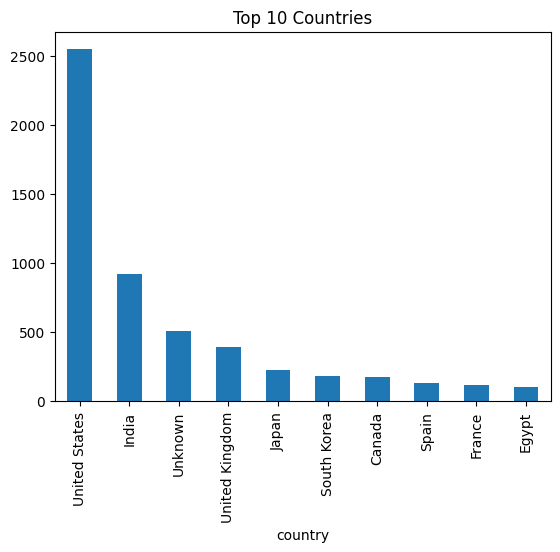

In [38]:
# Top Countries
df['country'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Countries")
plt.show()

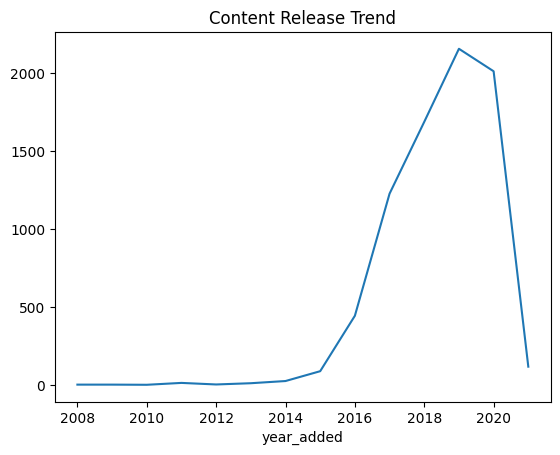

In [42]:
# Release Year Trend
df['year_added'].value_counts().sort_index().plot()
plt.title("Content Release Trend")
plt.show()